# 03 · Chapter 2: The LLM teaches a small ML model (the receptionist)

**The idea:** most messages are simple and repetitive. Why pay a genius (a big LLM) to answer them?

**My plan:**
1. Ask the LLM to label our training messages (it's the "teacher")
2. Check how good the LLM's labels are
3. Train small ML models on those labels and compare a few
4. Look at the model's *confidence* and pick a safe threshold
5. Save the best model

In [1]:
import sys
sys.path.append("..")   # so Python can find the budget_agent folder

import pandas as pd
pd.set_option("display.max_colwidth", 80)
from budget_agent import config, data

messages = data.load_messages()
train = messages[messages.split == "train"]
test = messages[messages.split == "test"]
messy = data.load_messy()
len(train), len(test), len(messy)

(1080, 540, 50)

## Step 1: The LLM labels the training messages

In a real company we would NOT have `true_intent`. We would only have the text.
So we pretend we don't have labels, and ask the LLM to make them.

The labelling code is in `budget_agent/labeler.py`. It sends 25 messages per request to save money.
Run it once from the terminal (takes a few minutes, costs well under $1):

```
uv run python run.py label
```

In [2]:
if config.LLM_LABELS_CSV.exists():
    labels = pd.read_csv(config.LLM_LABELS_CSV)
    train = train.merge(labels, on="id")
    print("Using the LLM's labels for", len(train), "messages")
else:
    train = train.assign(llm_intent=train.true_intent)
    print("No LLM labels yet, so I'm using the TRUE labels for now.")
    print("Run `uv run python run.py label`, then run this notebook again.")

Using the LLM's labels for 1080 messages


## Step 2: How good is the LLM as a teacher?

In [3]:
agree = (train.llm_intent == train.true_intent).mean()
print(f"The LLM's labels match the true labels {agree:.1%} of the time")

The LLM's labels match the true labels 91.5% of the time


In [4]:
# Where does the LLM disagree with the dataset?
train[train.llm_intent != train.true_intent][["text", "true_intent", "llm_intent"]].head(10)

,text,true_intent,llm_intent
2,I don't know what I have to do to speak to somebody,contact_human_agent,contact_customer_service
8,assistance to see the invoice from Rahul,check_invoice,get_invoice
11,I do not know how to cancel my premium account,delete_account,cancel_order
15,"I want to check the bill from Rahul, could you help me?",check_invoice,get_invoice
18,I don't know what to do ti see my invoice from Rahul,check_invoice,get_invoice
19,I need assistance to take a quick look at bill #85632,check_invoice,get_invoice
21,i want help submitting a different delivery address,set_up_shipping_address,change_shipping_address
50,"I need to use the gold profile, how can I do it?",switch_account,edit_account
58,using premium accouny,switch_account,edit_account
65,find bill #00108,check_invoice,get_invoice


Some "mistakes" are honestly debatable (e.g. *check_invoice* vs *get_invoice*, or *track_refund* vs *get_refund*). Labels made by people are never perfect either.

## Step 3: Train ML models and compare

Computers need numbers, not words. So first we turn text into numbers, then we train a classifier.

### Try 1: count words + Naive Bayes (the classic beginner model)

In [5]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

def check(model):
    model.fit(train.text, train.llm_intent)
    clean = (model.predict(test.text) == test.true_intent).mean()
    hard = (model.predict(messy.text) == messy.true_intent).mean()
    print(f"clean test: {clean:.1%}   messy: {hard:.1%}")
    return model

try1 = check(make_pipeline(CountVectorizer(), MultinomialNB()))

clean test: 85.6%   messy: 52.0%


Good on clean messages, but only about half right on messy ones. Typos like "ordr" or "pasword" are brand new words to this model.

### Try 2: TF-IDF + Logistic Regression
TF-IDF gives *rare, meaningful* words more weight than common words like "the".

In [6]:
try2 = check(make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=2000)))

clean test: 88.9%   messy: 48.0%


Better on clean, still bad on messy.

### Try 3: look at pieces of words instead of whole words
`analyzer="char_wb"` splits words into small chunks: "order" → "or", "ord", "rde", "der"...
So "ordr" still shares most chunks with "order". This should help with typos.

In [7]:
try3 = check(make_pipeline(TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5)),
                          LogisticRegression(max_iter=2000)))

clean test: 92.0%   messy: 58.0%


Best so far. 🎉 But for a receptionist I care about **confidence** too, not only accuracy: it must know when to pass a message on.

## Step 4: How confident is the model?

In [8]:
confidence = try3.predict_proba(test.text).max(axis=1)
print(f"Average confidence on clean test messages: {confidence.mean():.0%}")

Average confidence on clean test messages: 46%


Hmm. It's usually *right*, but it's never *sure* (average below 50%). If the receptionist only answers when it's 80% sure, it would almost never answer!

Logistic Regression has a setting `C`. A bigger `C` = less "holding back" = sharper, more confident probabilities.
Let me also ignore chunks seen only once (`min_df=2`). This is what I saved in `budget_agent/classifier.py`:

In [9]:
from budget_agent import classifier

final = check(classifier.make_model())
confidence = final.predict_proba(test.text).max(axis=1)
print(f"Average confidence on clean test messages: {confidence.mean():.0%}")

clean test: 92.4%   messy: 58.0%
Average confidence on clean test messages: 86%


Higher accuracy AND much more confident. This is the one.

## Step 5: Pick a safe confidence threshold

If the model is X% sure, how often is it right? And how many messages are that sure?
(I mix clean + messy messages here, like a real inbox.)

In [10]:
inbox = pd.concat([test[["text", "true_intent"]], messy])
probs = final.predict_proba(inbox.text)
inbox["confidence"] = probs.max(axis=1)
inbox["correct"] = final.classes_[probs.argmax(axis=1)] == inbox.true_intent

rows = []
for threshold in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    sure = inbox[inbox.confidence >= threshold]
    rows.append({"threshold": threshold,
                 "messages it would answer": f"{len(sure) / len(inbox):.0%}",
                 "accuracy on those": f"{sure.correct.mean():.1%}"})
pd.DataFrame(rows)

,threshold,messages it would answer,accuracy on those
0,0.4,96%,92.6%
1,0.5,92%,93.8%
2,0.6,86%,95.7%
3,0.7,82%,97.1%
4,0.8,72%,98.3%
5,0.9,52%,98.7%


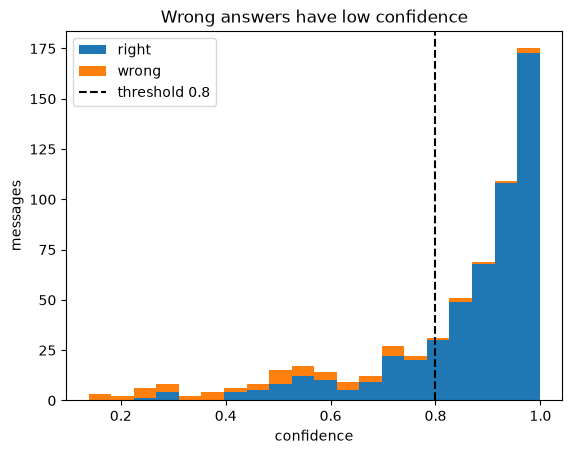

In [11]:
import matplotlib.pyplot as plt

plt.hist([inbox[inbox.correct].confidence, inbox[~inbox.correct].confidence],
         bins=20, label=["right", "wrong"], stacked=True)
plt.axvline(0.8, color="black", linestyle="--", label="threshold 0.8")
plt.xlabel("confidence"); plt.ylabel("messages"); plt.legend(); plt.title("Wrong answers have low confidence");

**This chart is the key idea of the support office:** wrong answers almost always come with low confidence.

So:
- **≥ 80% sure** → let the ML model answer (it's right about 98% of the time there)
- **less sure** → ask a smarter model

That's `ML_CONFIDENCE = 0.80` in `budget_agent/config.py`.

## Step 6: How fast is it?

In [12]:
import time

start = time.perf_counter()
final.predict(list(test.text))
ms = (time.perf_counter() - start) / len(test) * 1000
print(f"{ms:.3f} milliseconds per message, and it costs $0")

0.048 milliseconds per message, and it costs $0


The cloud LLM took a few **seconds** per message. The ML model takes a tiny fraction of a **millisecond**.

## Step 7: Save it

In [13]:
classifier.save(final)
print("Saved to models/" + config.CLASSIFIER_PATH.name)

Saved to models/intent_classifier.joblib


## What I learned
- The LLM can be a **teacher**: it labels data, and a small model learns from it. (Big AI labs call this *distillation*.)
- The student can't be better than its teacher: trained on the LLM's labels it gets about 92% right, versus about 98% when trained on perfect labels. Better labels = better model.
- Small pieces of words (char n-grams) handle typos much better than whole words.
- **Confidence matters as much as accuracy.** It tells us when to trust the small model.
- Messy messages are still hard, but the model *knows* it's unsure, so they can go to a smarter model.

Next: a free LLM on my own laptop → `04_hello_ollama.ipynb`